# 03 · Análisis e hipótesis: ¿quién puede pagar hoy un hipotecario UVA?

**Decisión que apoya:** a qué hogares apuntar, con qué producto y con qué política de riesgo (`reports/00_encuadre.md`).

1. Contexto de mercado: crédito, destino y cuánta vivienda compra un sueldo
2. El embudo de elegibilidad
3. H1 · ¿Cuántos pueden pagar? Mapa de calor por superficie
4. H2 · ¿Frena la cuota o el anticipo?
5. H3 · Composición del hogar (descriptivo)
6. H4 · Diferencias por zona y edad
7. H5 · Riesgo: la cuota frente a los sueldos
8. Recuadro H7 · Trabajos en el hogar (posible punto de fuga)
9. Robustez: Censo, subdeclaración y no respuesta
10. Tablero de hipótesis

> Las funciones de cálculo viven en `src/affordability.py` y `src/analysis.py`; son las mismas que alimentan el dashboard, los documentos y la presentación.

In [1]:
import sys, json, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

import config
import viz
import analysis as A
from affordability import ETAPAS, GBA, Producto, cargar_inquilinos, embudo, evaluar, parametros_mercado
from formato import fmt_cantidad, fmt_hogares, fmt_mes, fmt_monto, fmt_pct, fmt_decimal

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
pd.set_option("display.max_columns", 30)

con = duckdb.connect(str(config.DB_PATH), read_only=True)
m = parametros_mercado(con)
h = cargar_inquilinos(con)
base = Producto()
ev = evaluar(h, m, base)
ev["zona"] = A.grupo_geografico(ev)
K = json.loads((config.PROCESSED / "resultados" / "kpis.json").read_text(encoding="utf-8"))
RAMPA = LinearSegmentedColormap.from_list("azul", ["#eef4fc"] + viz.BLUE_RAMP)

def tinta_sobre(valor, vmin, vmax):
    """Texto blanco sobre celdas oscuras y tinta sobre celdas claras (según luminancia del color de fondo)."""
    r, g, b, _ = RAMPA((valor - vmin) / (vmax - vmin))
    return "#ffffff" if 0.2126 * r + 0.7152 * g + 0.0722 * b < 0.45 else viz.INK
print(f"UVA ${m['uva']:,.2f} ({m['fecha_uva']}) · dólar minorista ${m['tc']:,.2f} ({m['fecha_tc']})")
print(f"Inquilinos con ingreso declarado: {len(h)} observaciones de {h.hogar_id.nunique()} hogares encuestados · representan {fmt_hogares(h.peso.sum())}")

UVA $2,116.04 (2026-09-13) · dólar minorista $1,531.73 (2026-09-11)
Inquilinos con ingreso declarado: 2028 observaciones de 1504 hogares encuestados · representan 1,2 millones hogares


## 1. Contexto de mercado
### 1.1 El crédito volvió, pero el stock real es la mitad del pico de 2018

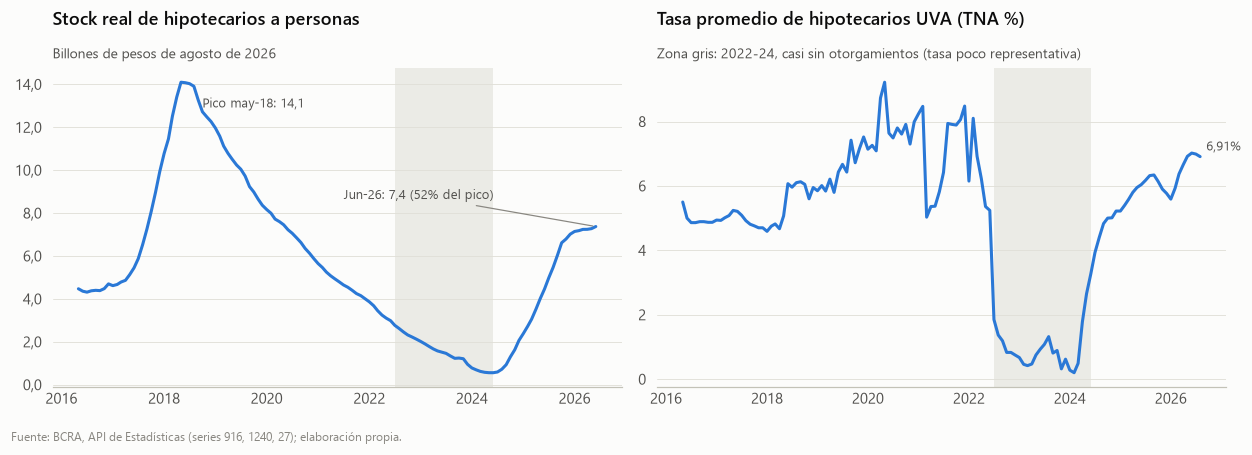

,rezago_meses,correlacion,n
0,0,-0.24,86
1,3,-0.26,86
2,6,-0.22,86
3,9,-0.27,86
4,12,-0.42,86


In [2]:
mc = con.execute("SELECT * FROM mart_mercado_credito ORDER BY mes").df()
hitos = K["contexto_mercado"]["hitos"]
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.9))
bajo = mc[mc.periodo_bajo_volumen]
for ax in axes:
    ax.axvspan(bajo.mes.min(), bajo.mes.max(), color=viz.GRID, alpha=0.6, lw=0)
ax = axes[0]
ax.plot(mc.mes, mc.stock_real_billones_ago26, color=viz.BLUE)
ax.set_title("Stock real de hipotecarios a personas")
viz.subtitle(ax, "Billones de pesos de agosto de 2026")
pico = mc.loc[mc.stock_real_billones_ago26.idxmax()]; ult = mc.dropna(subset=["stock_real_billones_ago26"]).iloc[-1]
ax.annotate(f"Pico may-18: {fmt_decimal(pico.stock_real_billones_ago26)}", (pico.mes, pico.stock_real_billones_ago26), xytext=(14, -10), textcoords="offset points", fontsize=8.5, color=viz.INK_2, va="top")
ax.annotate(f"{fmt_mes(ult.mes).capitalize()}: {fmt_decimal(ult.stock_real_billones_ago26)} ({fmt_pct(hitos['pct_del_pico'], 0)} del pico)", (ult.mes, ult.stock_real_billones_ago26), xytext=(-165, 18), textcoords="offset points", fontsize=8.5, color=viz.INK_2, arrowprops=dict(arrowstyle="-", color=viz.MUTED, lw=0.8))
ax.yaxis.set_major_formatter(viz.EJE_DECIMAL)
ax = axes[1]
ax.plot(mc.mes, mc.tasa_hip_uva, color=viz.BLUE)
ax.set_title("Tasa promedio de hipotecarios UVA (TNA %)")
viz.subtitle(ax, "Zona gris: 2022-24, casi sin otorgamientos (tasa poco representativa)")
t = mc.dropna(subset=["tasa_hip_uva"]).iloc[-1]
ax.annotate(fmt_pct(t.tasa_hip_uva, 2), (t.mes, t.tasa_hip_uva), xytext=(4, 4), textcoords="offset points", fontsize=8.5, color=viz.INK_2)
viz.source(fig, "BCRA, API de Estadísticas (series 916, 1240, 27); elaboración propia.")
fig.tight_layout()
viz.save(fig, "03_mercado_credito")
plt.show()
pd.DataFrame(K["contexto_mercado"]["correlaciones"]).round(2)

**Lectura (contexto, ex H6):** el stock real llegó a 14,1 billones en 2018-05, cayó a 0,56 en 2024-06 y hoy está en 7,4 (52% del pico). La relación entre tasa y crecimiento del stock es **débil y negativa**; con pocos ciclos y muchos factores a la vez (inflación, cepo, programas oficiales) se usa como **contexto, no como hipótesis causal**.

### 1.2 ¿Para qué se usa el crédito hipotecario?

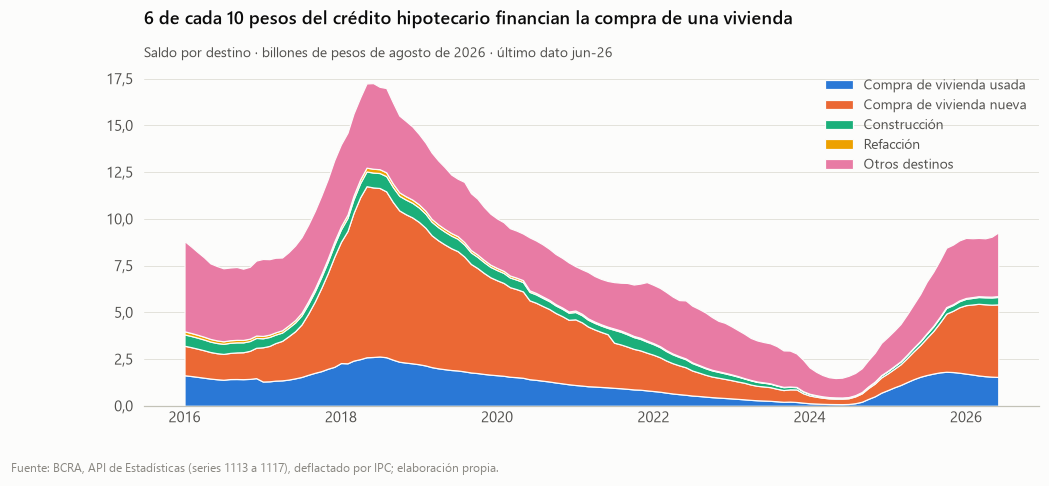

,mes,compra_usada,compra_nueva,construccion,refaccion,otros,pct_compra_usada
0,2018-05,2.60,9.15,0.79,0.20,4.51,15.10
1,2024-06,0.09,0.29,0.06,0.01,1.06,6.00
2,2026-06,1.54,3.88,0.40,0.04,3.41,16.60


In [3]:
dest = con.execute("SELECT * FROM mart_destino_credito ORDER BY mes").df()
series = [("compra_usada_billones_ago26", "Compra de vivienda usada"), ("compra_nueva_billones_ago26", "Compra de vivienda nueva"),
          ("construccion_billones_ago26", "Construcción"), ("refaccion_billones_ago26", "Refacción"), ("otros_billones_ago26", "Otros destinos")]
fig, ax = plt.subplots(figsize=(10.5, 4.0))
ax.stackplot(dest.mes, *[dest[c] for c, _ in series], labels=[l for _, l in series], colors=viz.SERIES[:5], edgecolor=viz.SURFACE, linewidth=0.8)
ax.yaxis.set_major_formatter(viz.EJE_DECIMAL)
ax.legend(loc="upper right", ncols=1)
u = dest.iloc[-1]
total = sum(u[c] for c, _ in series)
compra = u.compra_usada_billones_ago26 + u.compra_nueva_billones_ago26
ax.set_title(f"{round(10 * compra / total)} de cada 10 pesos del crédito hipotecario financian la compra de una vivienda")
viz.subtitle(ax, f"Saldo por destino · billones de pesos de agosto de 2026 · último dato {fmt_mes(u.mes)}")
viz.source(fig, "BCRA, API de Estadísticas (series 1113 a 1117), deflactado por IPC; elaboración propia.")
viz.save(fig, "03_destino_credito")
plt.show()
pd.DataFrame(K["contexto_mercado"]["destino_ultimo"])

**Lectura:** en 2026-06 el 58% del saldo financia compra de vivienda (nueva o usada). Construcción y refacción son marginales: el producto relevante para inquilinos es **compra**.

### 1.3 ¿Cuántos m² de CABA compra un sueldo formal?

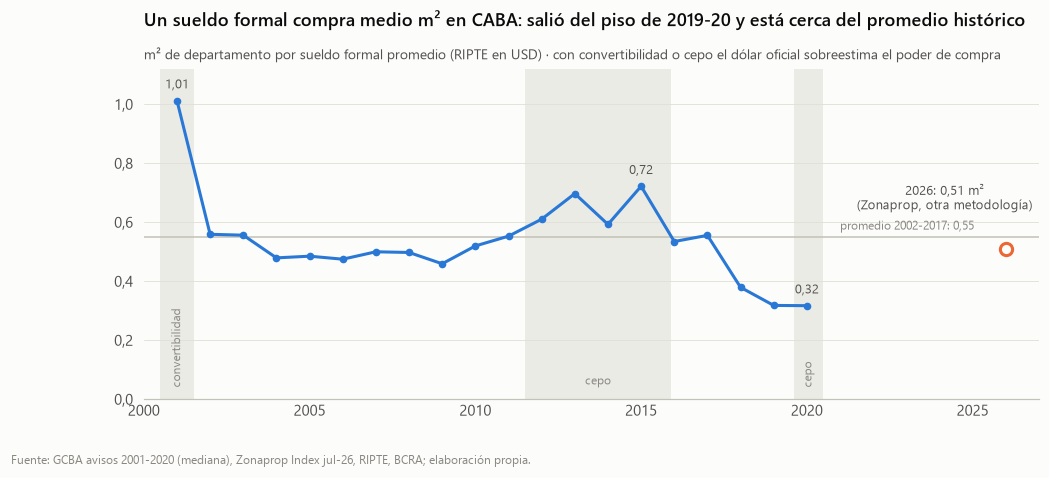

,anio,fuente_precio,usd_m2_mediana,ripte_usd,m2_por_salario,anios_de_salario_60m2
0,2001,GCBA avisos (mediana),871.84,882.72,1.01,4.56
1,2002,GCBA avisos (mediana),470.96,263.37,0.56,8.25
2,2003,GCBA avisos (mediana),571.43,317.82,0.56,8.30
3,2004,GCBA avisos (mediana),773.44,370.69,0.48,9.63
4,2005,GCBA avisos (mediana),866.67,420.34,0.49,9.52
5,2006,GCBA avisos (mediana),"1,051.53",499.25,0.47,9.72
6,2007,GCBA avisos (mediana),"1,205.88",602.83,0.50,9.23
7,2008,GCBA avisos (mediana),"1,532.66",762.61,0.50,9.28
8,2009,GCBA avisos (mediana),"1,607.84",738.54,0.46,10.05
9,2010,GCBA avisos (mediana),"1,708.86",888.19,0.52,8.88


In [4]:
ms = con.execute("SELECT * FROM mart_m2_por_salario ORDER BY anio").df()
hist = ms[ms.anio <= 2020]; hoy = ms[ms.anio == 2026].iloc[0]
fig, ax = plt.subplots(figsize=(10.5, 3.9))
for a, b_, txt in [(2000.5, 2001.5, "convertibilidad"), (2011.5, 2015.9, "cepo"), (2019.6, 2020.5, "cepo")]:
    ax.axvspan(a, b_, color=viz.GRID, alpha=0.6, lw=0)
    ax.text((a + b_) / 2, 0.04, txt, ha="center", fontsize=8, color=viz.MUTED, rotation=90 if b_ - a < 1.5 else 0, va="bottom")
prom = hist[(hist.anio >= 2002) & (hist.anio <= 2017)].m2_por_salario.mean()
ax.axhline(prom, color=viz.BASELINE, lw=1)
ax.text(2021, prom + 0.015, f"promedio 2002-2017: {fmt_decimal(prom, 2)}", fontsize=8, color=viz.MUTED, va="bottom")
ax.yaxis.set_major_formatter(viz.EJE_DECIMAL)
ax.plot(hist.anio, hist.m2_por_salario, color=viz.BLUE, marker="o", ms=4)
ax.plot([hoy.anio], [hoy.m2_por_salario], marker="o", ms=8, mfc=viz.SURFACE, mec=viz.ORANGE, mew=2, ls="none")
ax.annotate(f"2026: {fmt_decimal(hoy.m2_por_salario, 2)} m²\n(Zonaprop, otra metodología)", (hoy.anio, hoy.m2_por_salario), xytext=(-40, 26), textcoords="offset points", fontsize=8.5, color=viz.INK_2, ha="center")
for yr in (2001, 2015, 2020):
    r = ms[ms.anio == yr].iloc[0]
    ax.annotate(fmt_decimal(r.m2_por_salario, 2), (yr, r.m2_por_salario), xytext=(0, 8), textcoords="offset points", ha="center", fontsize=8.5, color=viz.INK_2)
ax.set_xlim(2000, 2027); ax.set_ylim(0, 1.12)
ax.set_title("Un sueldo formal compra medio m² en CABA: salió del piso de 2019-20 y está cerca del promedio histórico")
viz.subtitle(ax, "m² de departamento por sueldo formal promedio (RIPTE en USD) · con convertibilidad o cepo el dólar oficial sobreestima el poder de compra")
viz.source(fig, "GCBA avisos 2001-2020 (mediana), Zonaprop Index jul-26, RIPTE, BCRA; elaboración propia.")
viz.save(fig, "03_m2_por_salario")
plt.show()
ms[["anio", "fuente_precio", "usd_m2_mediana", "ripte_usd", "m2_por_salario", "anios_de_salario_60m2"]].round(2)

## 2. El embudo de elegibilidad

**Escenario base** (Checkpoints 1 y 2): UVA + 7,5% · 20 años · 75% financiado · cuota hasta 25% del ingreso · anticipo + gastos hasta 12 ingresos mensuales · ingreso demostrable (jefe/a o cónyuge asalariado con aportes) · edad al terminar hasta 85 años.

**Qué es un hogar inquilino:** un hogar (personas que comparten la vivienda y los gastos de comida) que declara alquilar la vivienda donde vive (EPH, pregunta II7 = 3). **Base:** los 1,2 millones de hogares inquilinos de los 3 mercados; el embudo se calcula sobre los que declararon su ingreso, con el peso `PONDIH` que representa también a los que no lo hicieron.

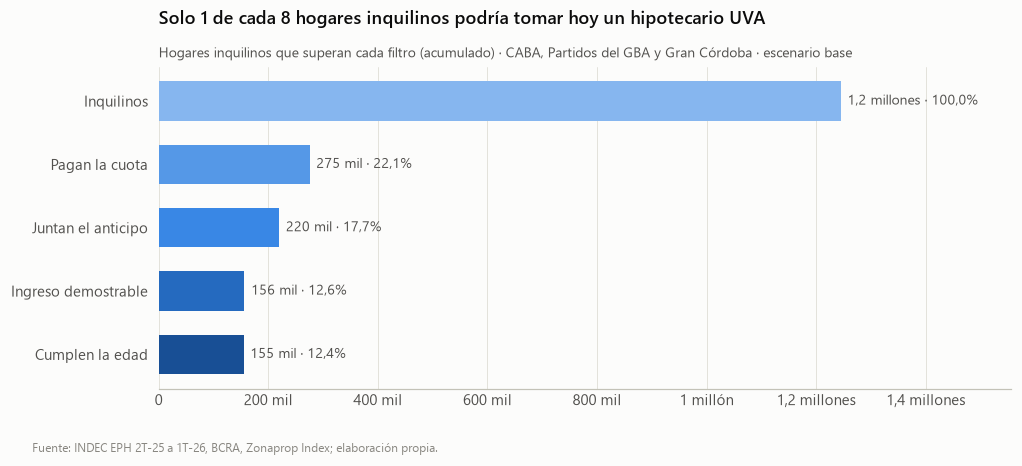

,etapa,hogares,pct_del_total,pct_de_etapa_anterior,muestra_hogares
0,Inquilinos,"1,244,787.75",100.00,100.00,1504
1,Pagan la cuota,"275,350.07",22.12,22.12,473
2,Juntan el anticipo,"219,882.48",17.66,79.86,397
3,Ingreso demostrable,"156,403.07",12.56,71.13,276
4,Cumplen la edad,"154,793.14",12.44,98.97,273


zona,CABA,GBA Norte,GBA Oeste,GBA Sur,Gran Córdoba
etapa,,,,,
Inquilinos,100.00,100.00,100.00,100.00,100.00
Pagan la cuota,20.60,16.50,26.80,20.80,27.80
Juntan el anticipo,15.40,13.50,22.80,16.90,22.50
Ingreso demostrable,10.80,9.50,16.70,12.00,15.80
Cumplen la edad,10.80,9.40,16.40,11.70,15.80


In [5]:
emb = embudo(ev)
fig, ax = plt.subplots(figsize=(10, 3.8))
colores = ["#86b6ef", "#5598e7", "#3987e5", "#256abf", "#184f95"]
y = np.arange(len(emb))[::-1]
ax.barh(y, emb.hogares, color=colores, height=0.62)
ax.set_yticks(y, emb.etapa)
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.xaxis.set_major_formatter(viz.EJE_CANTIDAD)
for yi, r in zip(y, emb.itertuples()):
    ax.text(r.hogares + emb.hogares.max() * 0.01, yi, f"{fmt_cantidad(r.hogares)} · {fmt_pct(r.pct_del_total)}", va="center", fontsize=9, color=viz.INK_2)
ax.set_xlim(0, emb.hogares.max() * 1.25)
pct_final = emb.pct_del_total.iloc[-1]
ax.set_title(f"Solo 1 de cada {round(100 / pct_final)} hogares inquilinos podría tomar hoy un hipotecario UVA")
viz.subtitle(ax, "Hogares inquilinos que superan cada filtro (acumulado) · CABA, Partidos del GBA y Gran Córdoba · escenario base")
viz.source(fig, "INDEC EPH 2T-25 a 1T-26, BCRA, Zonaprop Index; elaboración propia.")
viz.save(fig, "03_embudo_elegibilidad")
plt.show()
display(emb)
embudo(ev, "zona").pivot(index="etapa", columns="zona", values="pct_del_total").loc[ETAPAS].round(1)

## 3. H1 · ¿Menos del 20% de los inquilinos puede pagar la cuota?

In [6]:
A.h1_intervalos(h, m, base)

,indicador,pct,ic95_inf,ic95_sup
0,Pagan la cuota,22.12,19.61,24.49
1,Elegibles (embudo completo),12.44,10.38,14.27


**Lectura H1:** el 22,1% de los hogares inquilinos puede pagar la cuota (IC 95% 19,6–24,5) y el **12,4% pasa el embudo completo** (IC 10,4–14,3), es decir **155 mil hogares** (169 mil a 176 mil ajustado al Censo). Veredicto: **en el límite: el intervalo incluye el 20%**.

> Los intervalos son aproximados: la base usuaria de la EPH no publica conglomerados ni estratos del diseño muestral, así que el bootstrap por hogar probablemente los subestima un poco.

### 3.1 Mapa de calor: ¿y si cambia la superficie?
**Decisión (Checkpoint 3):** no fijar una regla de m² por tamaño de hogar. En lugar de eso, se muestra qué pasa con la elegibilidad si todos buscaran la misma superficie, de 30 a 90 m². La regla de referencia (45 m² hasta 2 personas, 60 m² para 3-4, 75 m² para 5 o más) queda marcada en el eje.

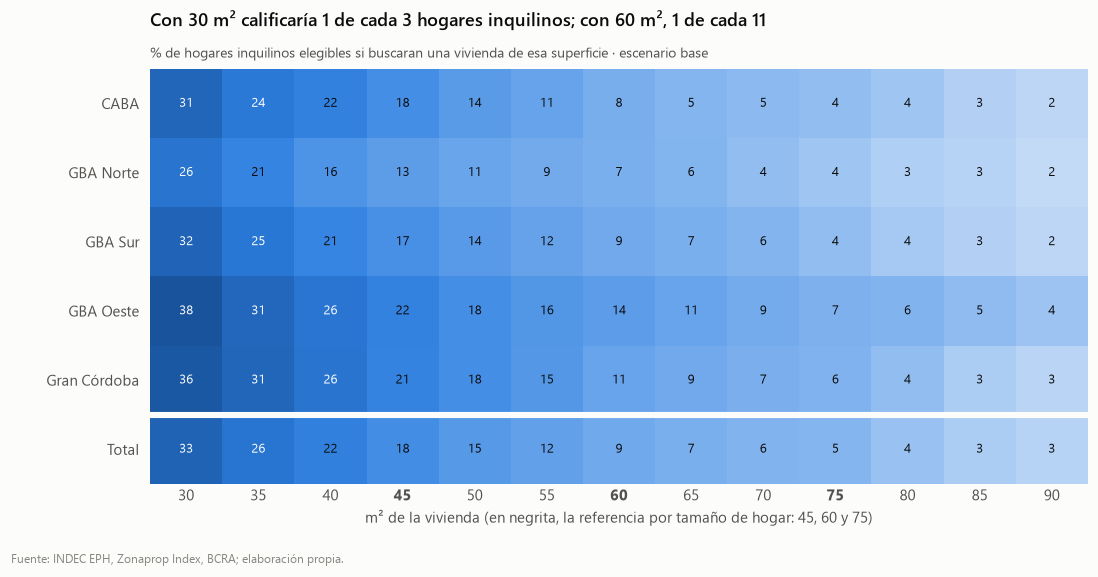

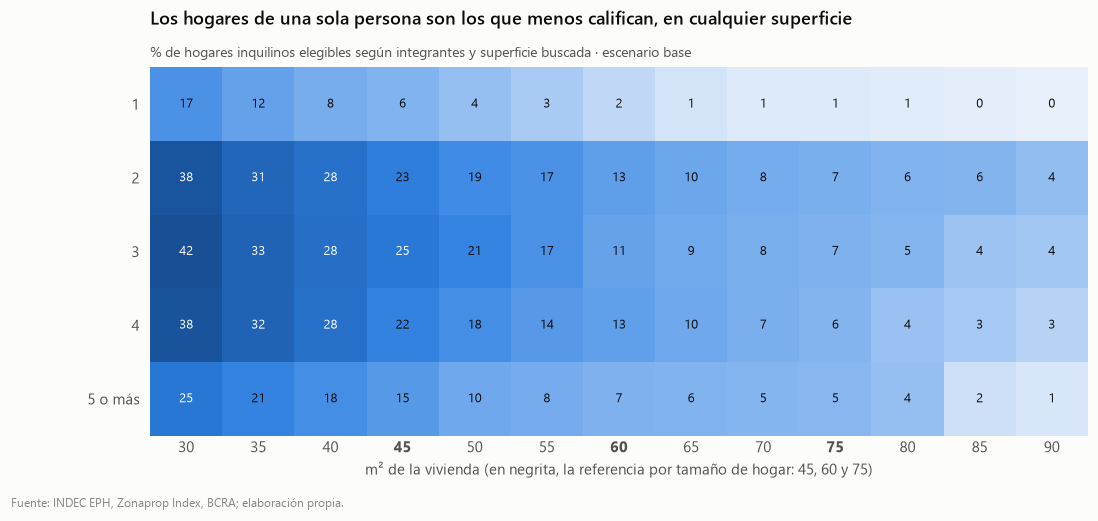

m2,30,35,40,45,50,55,60,65,70,75,80,85,90
zona,,,,,,,,,,,,,
CABA,31.30,24.50,21.80,17.80,13.80,11.30,7.50,5.40,4.70,4.40,3.80,2.90,2.40
GBA Norte,26.30,20.80,16.30,13.40,10.80,8.90,7.20,5.80,4.40,3.80,3.10,2.70,2.20
GBA Sur,31.80,25.30,20.60,17.20,14.30,11.60,9.20,7.30,5.60,4.50,3.60,2.90,2.40
GBA Oeste,38.10,30.70,25.90,21.60,17.70,15.60,13.50,11.00,8.50,6.80,6.00,4.70,4.00
Gran Córdoba,36.40,31.30,26.30,21.30,17.70,15.00,11.00,9.10,7.40,6.40,4.40,3.20,2.60
Total,32.50,26.10,22.10,18.10,14.60,12.30,9.30,7.30,5.90,5.00,4.10,3.20,2.70


m2,30,35,40,45,50,55,60,65,70,75,80,85,90
integrantes,,,,,,,,,,,,,
1,16.60,11.80,7.70,5.80,4.30,3.40,2.30,1.40,0.90,0.80,0.60,0.50,0.40
2,37.80,31.30,27.60,22.70,18.60,16.70,12.90,10.10,8.40,7.20,6.10,5.60,4.40
3,41.70,32.70,28.40,24.80,20.70,16.60,11.40,9.20,7.50,6.60,5.50,4.00,3.60
4,38.30,32.20,27.80,21.50,17.80,14.40,12.60,9.70,7.40,5.50,4.10,3.50,2.70
5 o más,25.10,21.10,17.80,14.50,9.60,8.10,6.60,5.90,5.10,4.90,4.40,1.60,1.10


In [7]:
calor_z, calor_i = A.h1_mapa_calor(h, m, base)

def mapa_calor(tabla, filas, titulo, bajada, archivo, etiqueta_filas):
    g = tabla.pivot(index=etiqueta_filas, columns="m2", values="pct_elegible").loc[filas]
    fig, ax = plt.subplots(figsize=(11, 0.55 * len(filas) + 1.6))
    ax.imshow(g.values, cmap=RAMPA, aspect="auto", vmin=0, vmax=40)
    ax.set_xticks(range(g.shape[1]), [f"{c}" for c in g.columns])
    ax.set_yticks(range(g.shape[0]), g.index)
    ax.grid(False)
    for s in ax.spines.values(): s.set_visible(False)
    for i in range(g.shape[0]):
        for j in range(g.shape[1]):
            v = g.values[i, j]
            ax.text(j, i, fmt_decimal(v, 0), ha="center", va="center", fontsize=8.5, color=tinta_sobre(min(v, 40), 0, 40))
    for c in (45, 60, 75):
        ax.get_xticklabels()[list(g.columns).index(c)].set_fontweight("bold")
    if "Total" in g.index:
        ax.axhline(len(g.index) - 1.5, color=viz.SURFACE, lw=4)
    ax.set_xlabel("m² de la vivienda (en negrita, la referencia por tamaño de hogar: 45, 60 y 75)")
    ax.set_title(titulo)
    viz.subtitle(ax, bajada)
    viz.source(fig, "INDEC EPH, Zonaprop Index, BCRA; elaboración propia.")
    viz.save(fig, archivo)
    plt.show()
    return g

tot = calor_z[calor_z.zona == "Total"].set_index("m2").pct_elegible
gz = mapa_calor(calor_z, ["CABA", "GBA Norte", "GBA Sur", "GBA Oeste", "Gran Córdoba", "Total"],
                f"Con 30 m² calificaría 1 de cada {round(100 / tot[30])} hogares inquilinos; con 60 m², 1 de cada {round(100 / tot[60])}",
                "% de hogares inquilinos elegibles si buscaran una vivienda de esa superficie · escenario base",
                "03_calor_m2_zona", "zona")
gi = mapa_calor(calor_i, ["1", "2", "3", "4", "5 o más"],
                "Los hogares de una sola persona son los que menos califican, en cualquier superficie",
                "% de hogares inquilinos elegibles según integrantes y superficie buscada · escenario base",
                "03_calor_m2_integrantes", "integrantes")
display(gz.round(1)); display(gi.round(1))

**Lectura:** con 45 m² (un 2 ambientes chico) calificaría el 18,1% de los inquilinos; con 60 m², el 9,3%; con 75 m², el 5,0%. En **CABA** la proporción pasa de 17,8% a 4,4% entre 45 y 75 m²; en **GBA Oeste**, de 21,6% a 6,8%. Los **hogares de una persona** tienen la elegibilidad más baja en cualquier superficie: dependen de un solo ingreso.

## 4. H2 · ¿La barrera es el anticipo o la cuota?
Con los supuestos del escenario, **cuota y anticipo dependen del mismo número**: cuánto cuesta la vivienda medido en ingresos mensuales del hogar.

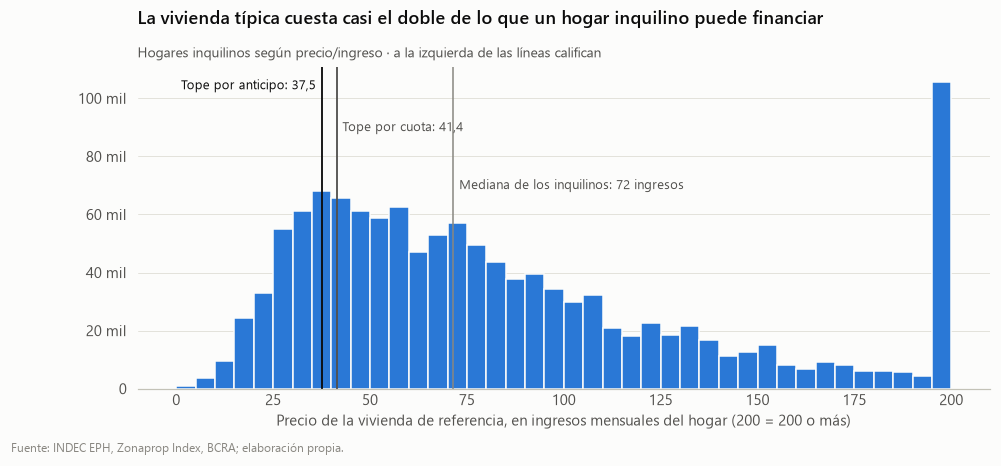

,valor
pct_fallan_ambos,77.88
pct_solo_falla_anticipo,4.46
pct_solo_falla_cuota,0.00
pct_pasan_ambos,17.66
precio_max_ingresos_por_cuota,41.38
precio_max_ingresos_por_anticipo,37.50
barrera_activa,anticipo
ltv_equilibrio,0.77
precio_max_ingresos_en_equilibrio,40.22
mediana_precio_en_ingresos,71.51


In [8]:
b = A.h2_barreras(ev, base)
ev["precio_en_ingresos"] = ev.precio_ars / ev.ingreso
mediana = A.wquant(ev.precio_en_ingresos, ev.peso, 0.5)
fig, ax = plt.subplots(figsize=(10, 3.8))
x = ev.precio_en_ingresos.clip(upper=200)
ax.hist(x, bins=np.arange(0, 205, 5), weights=ev.peso, color=viz.BLUE, edgecolor=viz.SURFACE, linewidth=1)
ax.axvline(b["precio_max_ingresos_por_anticipo"], color=viz.INK, lw=1.2)
ax.axvline(b["precio_max_ingresos_por_cuota"], color=viz.INK_2, lw=1.2)
ymax = ax.get_ylim()[1]
ax.text(b["precio_max_ingresos_por_anticipo"] - 1.5, ymax * 0.93, f"Tope por anticipo: {fmt_decimal(b['precio_max_ingresos_por_anticipo'])}", ha="right", fontsize=8.5, color=viz.INK)
ax.text(b["precio_max_ingresos_por_cuota"] + 1.5, ymax * 0.80, f"Tope por cuota: {fmt_decimal(b['precio_max_ingresos_por_cuota'])}", ha="left", fontsize=8.5, color=viz.INK_2)
ax.axvline(mediana, color=viz.MUTED, lw=1)
ax.text(mediana + 1.5, ymax * 0.62, f"Mediana de los inquilinos: {fmt_decimal(mediana, 0)} ingresos", ha="left", fontsize=8.5, color=viz.INK_2)
ax.yaxis.set_major_formatter(viz.EJE_CANTIDAD)
ax.set_xlabel("Precio de la vivienda de referencia, en ingresos mensuales del hogar (200 = 200 o más)")
ax.set_title("La vivienda típica cuesta casi el doble de lo que un hogar inquilino puede financiar")
viz.subtitle(ax, "Hogares inquilinos según precio/ingreso · a la izquierda de las líneas califican")
viz.source(fig, "INDEC EPH, Zonaprop Index, BCRA; elaboración propia.")
viz.save(fig, "03_precio_en_ingresos")
plt.show()
pd.Series(b).to_frame("valor")

**Lectura H2:** en sentido estricto, **el anticipo es la restricción más exigente**: una vivienda puede costar hasta 37,5 ingresos por el anticipo y 41,4 por la cuota, y ningún hogar pasa el anticipo sin pasar la cuota. Pero el **78% no alcanza ninguna de las dos**: la vivienda de referencia cuesta una mediana de 72 ingresos mensuales.

**Implicancia de producto:** bajar la tasa, alargar el plazo o subir el tope de cuota **no suma hogares por sí solos** (mueven la línea de la cuota, que no es la que frena). El % financiado de equilibrio es 77%: la palanca real es **financiar más junto con más plazo** (notebook 04).

## 5. H3 · ¿Cómo son los hogares inquilinos y quiénes califican?
**Decisión (Checkpoint 3):** mirada **descriptiva y neutral**. Se describe la composición del hogar y, dentro de ella, quién figura como jefe o jefa (la persona que el propio hogar reconoce como tal en la encuesta). No se hacen afirmaciones causales.

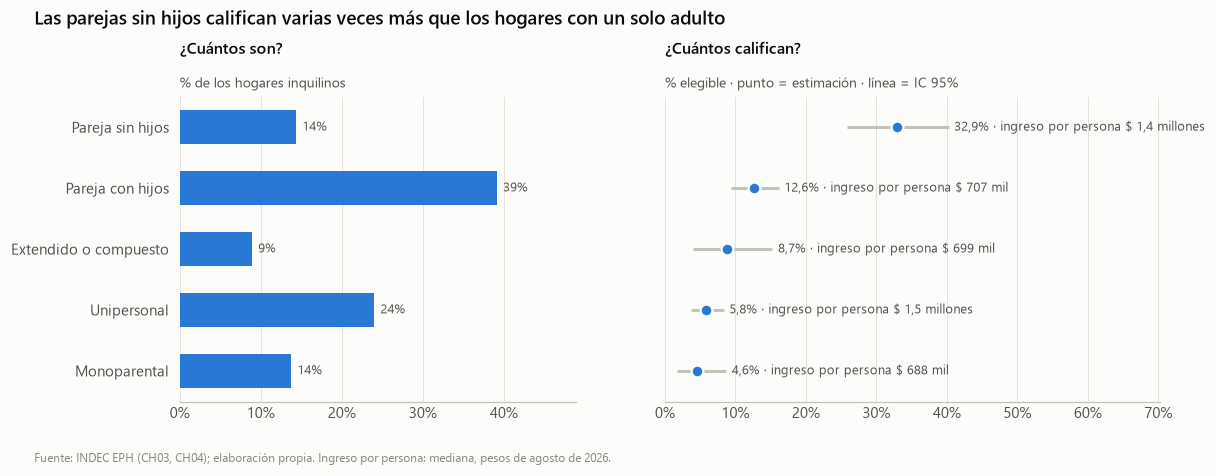

,agrupacion,tipo_hogar,jefatura,hogares,pct_de_inquilinos,muestra_hogares,ingreso_mediano,ingreso_por_persona_mediano,perceptores_promedio,pct_ingreso_demostrable,pct_elegible,ic95_inf,ic95_sup,muestra_chica
0,tipo_hogar,Extendido o compuesto,Todas,"110,536.00",8.90,143,"2,337,231.20","698,855.50",2.30,34.80,8.70,4.00,15.20,False
1,tipo_hogar,Monoparental,Todas,"170,796.20",13.70,231,"1,775,318.40","687,647.30",1.40,46.20,4.60,1.70,8.70,False
2,tipo_hogar,Pareja con hijos,Todas,"486,708.20",39.10,405,"2,536,169.10","706,913.10",1.90,67.10,12.60,9.30,16.10,False
3,tipo_hogar,Pareja sin hijos,Todas,"178,353.50",14.30,237,"2,784,644.00","1,392,322.00",1.90,73.70,32.90,25.80,40.20,False
4,tipo_hogar,Unipersonal,Todas,"298,393.80",24.00,515,"1,549,881.10","1,549,881.10",1.00,44.70,5.80,3.70,8.30,False
5,jefatura,Todos,Mujer,"542,450.20",43.60,760,"1,972,576.00","834,725.40",1.60,51.30,10.20,7.80,13.00,False
6,jefatura,Todos,Varón,"702,337.50",56.40,756,"2,395,270.80","1,056,737.10",1.70,61.30,14.20,11.60,16.90,False
7,tipo_hogar × jefatura,Extendido o compuesto,Mujer,"45,118.20",3.60,82,"2,043,407.80","651,654.60",2.10,28.10,3.50,1.00,6.50,False
8,tipo_hogar × jefatura,Extendido o compuesto,Varón,"65,417.80",5.30,62,"2,869,235.70","798,396.00",2.40,39.30,12.30,4.90,23.20,False
9,tipo_hogar × jefatura,Monoparental,Mujer,"138,540.00",11.10,194,"1,669,450.90","611,242.10",1.30,44.50,1.90,0.60,3.80,False


In [9]:
h3 = A.h3_perfil_hogares(h, m, base)
orden = ["Pareja sin hijos", "Pareja con hijos", "Extendido o compuesto", "Unipersonal", "Monoparental"]
t = h3[h3.agrupacion == "tipo_hogar"].set_index("tipo_hogar").loc[orden]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 3.6), sharey=True, gridspec_kw={"width_ratios": [1, 1.25]})
y = np.arange(len(t))[::-1]
a1.barh(y, t.pct_de_inquilinos, color=viz.BLUE, height=0.55)
for yi, r in zip(y, t.itertuples()):
    a1.text(r.pct_de_inquilinos + 0.8, yi, fmt_pct(r.pct_de_inquilinos, 0), va="center", fontsize=8.5, color=viz.INK_2)
a1.set_yticks(y, t.index); a1.set_xlim(0, t.pct_de_inquilinos.max() * 1.25)
a1.grid(axis="y", visible=False); a1.grid(axis="x", visible=True); a1.xaxis.set_major_formatter(viz.EJE_PCT)
a1.set_title("¿Cuántos son?", fontsize=10.5); viz.subtitle(a1, "% de los hogares inquilinos")
a2.errorbar(t.pct_elegible, y, xerr=[t.pct_elegible - t.ic95_inf, t.ic95_sup - t.pct_elegible], fmt="none", ecolor=viz.BASELINE, elinewidth=2)
a2.scatter(t.pct_elegible, y, s=60, color=viz.BLUE, zorder=3, edgecolor=viz.SURFACE, linewidth=1.5)
for yi, r in zip(y, t.itertuples()):
    a2.text(r.ic95_sup + 0.8, yi, f"{fmt_pct(r.pct_elegible)} · ingreso por persona {fmt_monto(r.ingreso_por_persona_mediano)}", va="center", fontsize=8.5, color=viz.INK_2)
a2.set_xlim(0, t.ic95_sup.max() + 30); a2.grid(axis="y", visible=False); a2.grid(axis="x", visible=True); a2.xaxis.set_major_formatter(viz.EJE_PCT)
a2.set_title("¿Cuántos califican?", fontsize=10.5); viz.subtitle(a2, "% elegible · punto = estimación · línea = IC 95%")
viz.titulo_figura(fig, "Las parejas sin hijos califican varias veces más que los hogares con un solo adulto")
viz.source(fig, "INDEC EPH (CH03, CH04); elaboración propia. Ingreso por persona: mediana, pesos de agosto de 2026.")
viz.save(fig, "03_perfil_hogares")
plt.show()
h3[["agrupacion", "tipo_hogar", "jefatura", "hogares", "pct_de_inquilinos", "muestra_hogares", "ingreso_mediano", "ingreso_por_persona_mediano",
    "perceptores_promedio", "pct_ingreso_demostrable", "pct_elegible", "ic95_inf", "ic95_sup", "muestra_chica"]].round(1)

**Lectura H3 (descriptiva):**
- Las **parejas con hijos** son el grupo más numeroso (39% de los inquilinos) y califica el 12,6%.
- Las **parejas sin hijos** tienen la mayor elegibilidad (32,9%): suelen tener dos ingresos y el ingreso por persona más alto.
- Los hogares con **un solo adulto** (unipersonales 5,8%, monoparentales 4,6%) dependen de un ingreso y quedan mayormente afuera.
- **Jefatura:** en las parejas, la elegibilidad es similar según quién figura como jefe/a (14,8% y 11,3% en parejas con hijos). Las diferencias aparecen en los hogares de un solo adulto, donde el ingreso por persona es más bajo cuando encabeza una mujer. Hay celdas con **muestra chica** (marcadas en la tabla): se muestran como referencia, no como conclusión.

## 6. H4 · ¿La elegibilidad cambia según la zona y la edad?

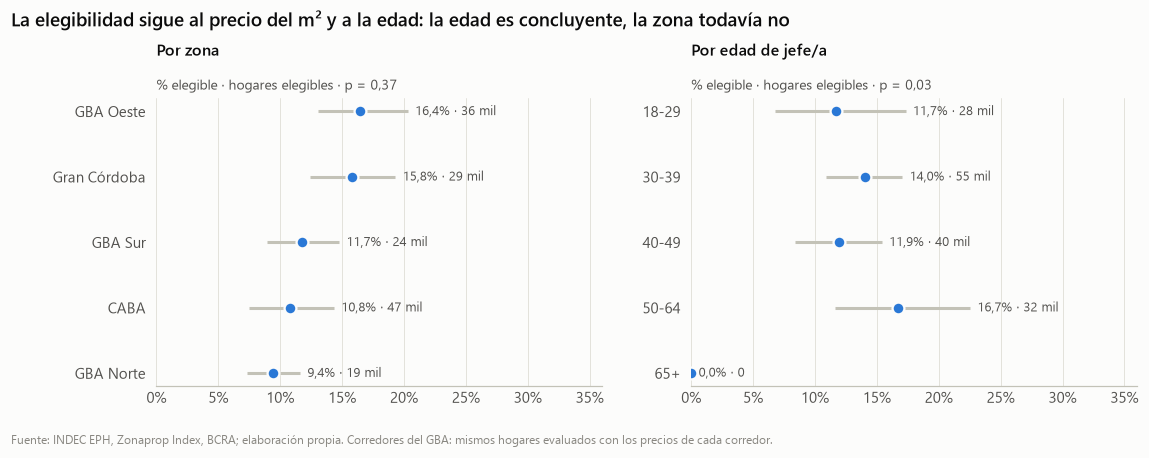

,zona,muestra_hogares,hogares,hogares_elegibles,pct_elegible,ic95_inf,ic95_sup
2,GBA Oeste,546,"219,356.70","35,989.55",16.41,13.08,20.30
4,Gran Córdoba,521,"180,864.50","28,575.75",15.80,12.38,19.30
3,GBA Sur,546,"208,587.06","24,478.59",11.74,8.90,14.75
0,CABA,437,"432,434.50","46,636.50",10.78,7.46,14.34
1,GBA Norte,546,"203,544.98","19,112.74",9.39,7.34,11.59


{'test_entre': 'mercado', 'chi2': np.float64(3.5982778031954914), 'deff_kish': np.float64(1.8035070838086185), 'chi2_ajustado': np.float64(1.9951559023526007), 'gl': 2, 'p_valor': np.float64(0.3687715430602471), 'diferencia_max_pp': np.float64(7.016928537850578), 'muestra_hogares': 1504}


,tramo_edad_jefe,muestra_hogares,hogares,hogares_elegibles,pct_elegible,ic95_inf,ic95_sup
3,50-64,245,"190,458.25","31,812.37",16.70,11.60,22.52
1,30-39,461,"390,465.50","54,664.28",14.00,10.87,17.05
2,40-49,357,"335,889.75","39,973.95",11.90,8.40,15.39
0,18-29,326,"242,850.50","28,342.53",11.67,6.74,17.31
4,65+,134,"85,123.75",0.00,0.00,0.00,0.00


{'test_entre': 'tramo_edad_jefe', 'chi2': np.float64(20.029397785520594), 'deff_kish': np.float64(1.8014989540213833), 'chi2_ajustado': np.float64(11.11818452117894), 'gl': 4, 'p_valor': np.float64(0.025267405294988755), 'diferencia_max_pp': np.float64(16.70306703993228), 'muestra_hogares': 1523}


In [10]:
t_zona, test_zona = A.h4_por_grupo(h, m, "zona", base)
t_edad, test_edad = A.h4_por_grupo(h, m, "tramo_edad_jefe", base)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.5, 3.4))
for ax, t, col, test, titulo in [(a1, t_zona, "zona", test_zona, "Por zona"), (a2, t_edad.sort_values("tramo_edad_jefe", ascending=False), "tramo_edad_jefe", test_edad, "Por edad de jefe/a")]:
    d = t.sort_values("pct_elegible") if col == "zona" else t
    y = np.arange(len(d))
    ax.errorbar(d.pct_elegible, y, xerr=[d.pct_elegible - d.ic95_inf, d.ic95_sup - d.pct_elegible], fmt="none", ecolor=viz.BASELINE, elinewidth=2)
    ax.scatter(d.pct_elegible, y, s=60, color=viz.BLUE, zorder=3, edgecolor=viz.SURFACE, linewidth=1.5)
    for yi, r in zip(y, d.itertuples()):
        ax.text(r.ic95_sup + 0.6, yi, f"{fmt_pct(r.pct_elegible)} · {fmt_cantidad(r.hogares_elegibles)}", va="center", fontsize=8.5, color=viz.INK_2)
    ax.set_yticks(y, d[col]); ax.set_xlim(0, 36)
    ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True); ax.xaxis.set_major_formatter(viz.EJE_PCT)
    ax.set_title(titulo, fontsize=10.5)
    viz.subtitle(ax, f"% elegible · hogares elegibles · p = {fmt_decimal(test['p_valor'], 2)}")
viz.titulo_figura(fig, "La elegibilidad sigue al precio del m² y a la edad: la edad es concluyente, la zona todavía no")
viz.source(fig, "INDEC EPH, Zonaprop Index, BCRA; elaboración propia. Corredores del GBA: mismos hogares evaluados con los precios de cada corredor.")
viz.save(fig, "03_elegibles_por_zona_edad")
plt.show()
display(t_zona); print(test_zona); display(t_edad); print(test_edad)

**Lectura H4:**
- **Zona:** la proporción de elegibles va de 9,4% en GBA Norte (m² más caro del conurbano) a 16,4% en GBA Oeste; Gran Córdoba tiene 15,8% y CABA 10,8%. Entre mercados la diferencia **no es estadísticamente concluyente** (p = 0,37, ajustado por efecto de diseño). En volumen, **CABA aporta la mayor cantidad de elegibles** (47 mil).
- **Edad:** diferencia significativa (p = 0,03). Con 20 años de plazo, desde los 66 años no se cumple la edad máxima; los grupos de 30-39 y 50-64 años son los de mayor elegibilidad.
- **Veredicto:** parcialmente confirmada (edad sí; zona, dirección esperada pero no concluyente).

## 7. H5 · Riesgo: ¿qué pasa si la UVA le gana a los sueldos?
**Cómo se lee el stress test, paso a paso:**
1. Un hogar toma el crédito con una cuota igual al 25% de su ingreso.
2. La cuota se mueve con la UVA (inflación) y el ingreso con el índice de salarios registrados.
3. Si los precios suben más rápido que los sueldos, la cuota pasa a pesar más del 25%.

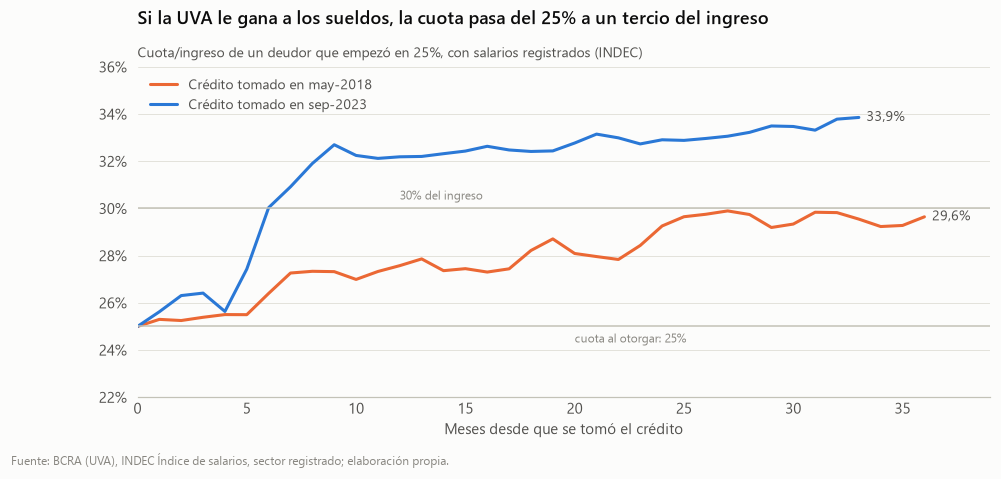

,horizonte_meses,ventanas,peor_cuota_ingreso_pct,inicio_peor_ventana,mejor_cuota_ingreso_pct,inicio_mejor_ventana,pct_ventanas_sobre_30
0,12,112,32.20,2023-09,22.40,2022-09,6.30
1,24,100,32.90,2023-09,21.30,2021-09,11.00
2,36,88,31.30,2023-05,20.80,2020-09,12.50


In [11]:
st = con.execute("SELECT * FROM mart_stress_uva_salarios").df()
res = pd.DataFrame(K["h5"]["stress_resumen"])
fig, ax = plt.subplots(figsize=(10, 3.9))
for inicio, color, etiqueta in [("2018-05-01", viz.ORANGE, "Crédito tomado en may-2018"), ("2023-09-01", viz.BLUE, "Crédito tomado en sep-2023")]:
    s = st[st.inicio == pd.Timestamp(inicio)].sort_values("meses_transcurridos")
    ax.plot(s.meses_transcurridos, 100 * s.cuota_ingreso, color=color, label=etiqueta)
    ax.annotate(fmt_pct(100 * s.cuota_ingreso.iloc[-1]), (s.meses_transcurridos.iloc[-1], 100 * s.cuota_ingreso.iloc[-1]), xytext=(5, 0), textcoords="offset points", va="center", fontsize=9, color=viz.INK_2)
for nivel, txt, x, dy, va in [(25, "cuota al otorgar: 25%", 20, -0.3, "top"), (30, "30% del ingreso", 12, 0.25, "bottom")]:
    ax.axhline(nivel, color=viz.BASELINE, lw=1)
    ax.text(x, nivel + dy, txt, fontsize=8, color=viz.MUTED, ha="left", va=va)
ax.set_xlim(0, 39); ax.set_ylim(22, 36)
ax.yaxis.set_major_formatter(viz.EJE_PCT)
ax.set_xlabel("Meses desde que se tomó el crédito")
ax.legend(loc="upper left")
ax.set_title("Si la UVA le gana a los sueldos, la cuota pasa del 25% a un tercio del ingreso")
viz.subtitle(ax, "Cuota/ingreso de un deudor que empezó en 25%, con salarios registrados (INDEC)")
viz.source(fig, "BCRA (UVA), INDEC Índice de salarios, sector registrado; elaboración propia.")
viz.save(fig, "03_stress_uva_salarios")
plt.show()
res

**Lectura:** un crédito tomado en **sep-2023** llegó a 32,9% del ingreso a los 24 meses. El 11% de todas las ventanas de 24 meses desde 2016 supera el 30%. **Implicancia:** otorgar con tope de cuota 30% (en vez de 25%) dejaría a esos deudores cerca del 40% en un episodio así → mantener el **25%** y evaluar protecciones (por ejemplo, un tope de cuota atado a salarios).

### 7.1 El sueldo en tres lentes
**Pedido del Checkpoint 3:** mostrar cómo evolucionaron los sueldos en el mismo período frente a la inflación y en dólares. Se usa la **mediana de la remuneración bruta de asalariados registrados del sector privado (SIPA)**; se excluyen junio y diciembre porque incluyen aguinaldo.

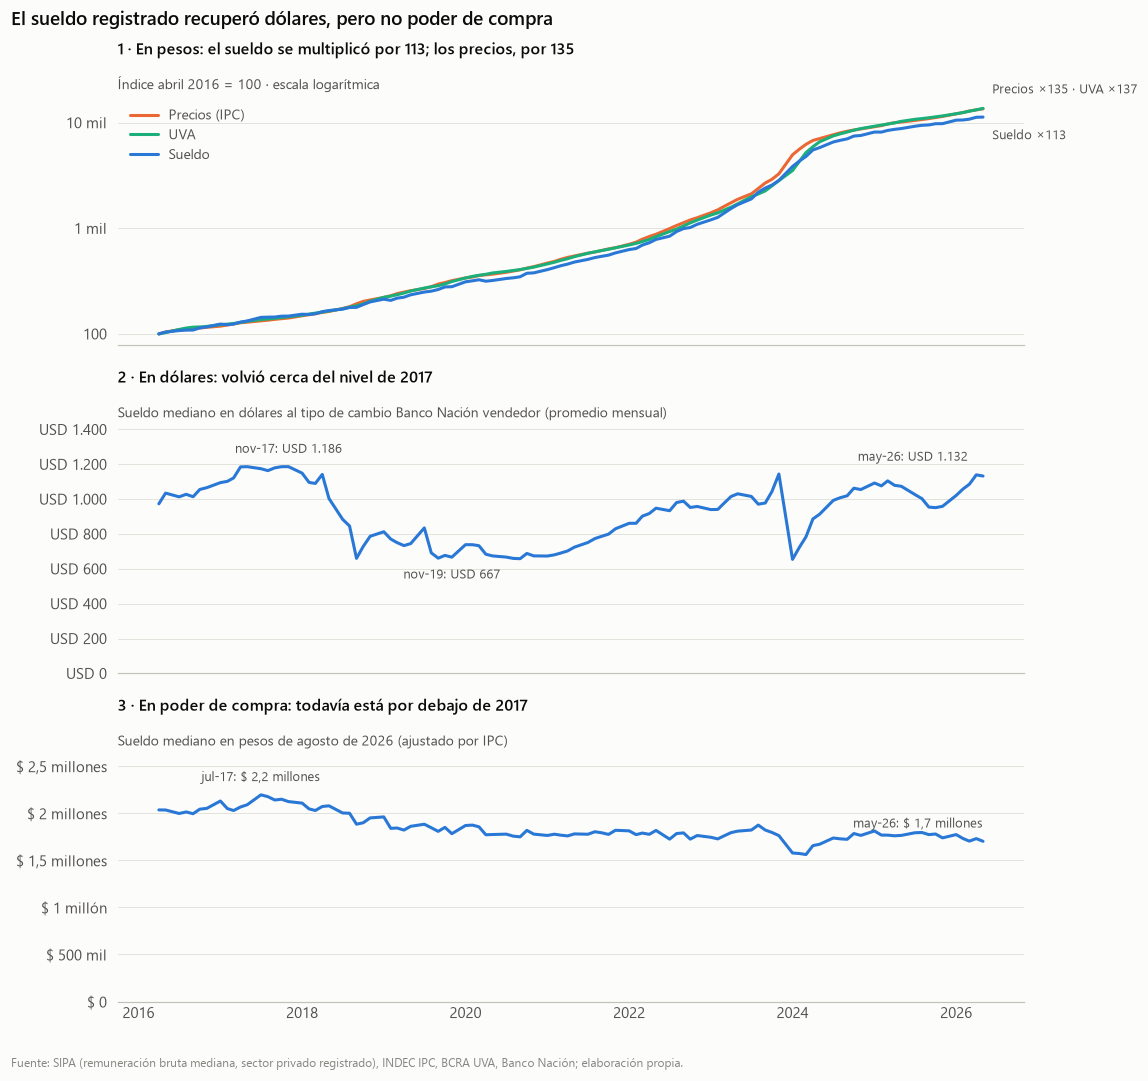

,mes,sueldo_bruto_mediano,sueldo_usd_bna,sueldo_real_ago26
0,2017-11,"20,992.00","1,186.00","2,123,973.00"
1,2018-05,"23,688.00","1,004.00","2,078,965.00"
2,2019-11,"39,828.00",667.00,"1,783,094.00"
3,2023-09,"342,177.00",978.00,"1,822,021.00"
4,2023-11,"404,395.00","1,144.00","1,762,670.00"
5,2024-05,"826,588.00",914.00,"1,671,081.00"
6,2025-05,"1,252,643.00","1,074.00","1,764,953.00"
7,2026-05,"1,608,683.00","1,132.00","1,702,124.00"


In [12]:
tl = con.execute("SELECT * FROM mart_sueldo_tres_lentes ORDER BY mes").df()
fig, axes = plt.subplots(3, 1, figsize=(10.5, 9.2), sharex=True)
ax = axes[0]
for col, color, nombre in [("indice_ipc", viz.ORANGE, "Precios (IPC)"), ("indice_uva", viz.AQUA, "UVA"), ("indice_sueldo", viz.BLUE, "Sueldo")]:
    ax.plot(tl.mes, tl[col], color=color, label=nombre)
u = tl.iloc[-1]
ax.annotate(f"Precios ×{fmt_decimal(u.indice_ipc / 100, 0)} · UVA ×{fmt_decimal(u.indice_uva / 100, 0)}", (u.mes, u.indice_uva), xytext=(6, 8), textcoords="offset points", fontsize=8.5, color=viz.INK_2, va="bottom")
ax.annotate(f"Sueldo ×{fmt_decimal(u.indice_sueldo / 100, 0)}", (u.mes, u.indice_sueldo), xytext=(6, -8), textcoords="offset points", fontsize=8.5, color=viz.INK_2, va="top")
ax.set_yscale("log")
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: fmt_cantidad(v)))
ax.yaxis.set_minor_formatter(mtick.NullFormatter())
ax.legend(loc="upper left")
ax.set_title(f"1 · En pesos: el sueldo se multiplicó por {fmt_decimal(tl.indice_sueldo.iloc[-1] / 100, 0)}; los precios, por {fmt_decimal(tl.indice_ipc.iloc[-1] / 100, 0)}", fontsize=10.5)
viz.subtitle(ax, "Índice abril 2016 = 100 · escala logarítmica")
ax = axes[1]
ax.plot(tl.mes, tl.sueldo_usd_bna, color=viz.BLUE)
for mes in ["2017-11-01", "2019-11-01"]:
    r = tl[tl.mes == pd.Timestamp(mes)].iloc[0]
    ax.annotate(f"{fmt_mes(r.mes)}: {fmt_monto(r.sueldo_usd_bna, 'USD', exacto=True)}", (r.mes, r.sueldo_usd_bna), xytext=(0, 9 if mes.startswith("2017") else -14), textcoords="offset points", ha="center", fontsize=8.5, color=viz.INK_2)
r = tl.iloc[-1]
ax.annotate(f"{fmt_mes(r.mes)}: {fmt_monto(r.sueldo_usd_bna, 'USD', exacto=True)}", (r.mes, r.sueldo_usd_bna), xytext=(-10, 10), textcoords="offset points", ha="right", fontsize=8.5, color=viz.INK_2)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: fmt_monto(v, "USD", exacto=True)))
ax.set_ylim(0, tl.sueldo_usd_bna.max() * 1.2)
ax.set_title("2 · En dólares: volvió cerca del nivel de 2017", fontsize=10.5)
viz.subtitle(ax, "Sueldo mediano en dólares al tipo de cambio Banco Nación vendedor (promedio mensual)")
ax = axes[2]
ax.plot(tl.mes, tl.sueldo_real_pesos_ago26, color=viz.BLUE)
for idx in [tl.sueldo_real_pesos_ago26.idxmax(), tl.index[-1]]:
    r = tl.loc[idx]
    ax.annotate(f"{fmt_mes(r.mes)}: {fmt_monto(r.sueldo_real_pesos_ago26)}", (r.mes, r.sueldo_real_pesos_ago26), xytext=(0, 9), textcoords="offset points", ha="center" if idx != tl.index[-1] else "right", fontsize=8.5, color=viz.INK_2)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: fmt_monto(v)))
ax.set_ylim(0, tl.sueldo_real_pesos_ago26.max() * 1.2)
ax.set_title("3 · En poder de compra: todavía está por debajo de 2017", fontsize=10.5)
viz.subtitle(ax, "Sueldo mediano en pesos de agosto de 2026 (ajustado por IPC)")
viz.source(fig, "SIPA (remuneración bruta mediana, sector privado registrado), INDEC IPC, BCRA UVA, Banco Nación; elaboración propia.")
fig.tight_layout()
viz.titulo_figura(fig, "El sueldo registrado recuperó dólares, pero no poder de compra")
viz.save(fig, "03_sueldo_tres_lentes")
plt.show()
pd.DataFrame(K["h5"]["sueldo_hitos"])

**Lectura:** el sueldo mediano registrado ($ 1,6 millones brutos en 2026-05) equivale a USD 1.132 al dólar Banco Nación, cerca de los USD 1.186 de nov-2017 y lejos del piso de USD 667 de nov-2019. En poder de compra, en cambio, vale $ 1,7 millones de agosto de 2026, contra $ 2,1 millones en 2017. Para quien compra en dólares y paga en UVA, las dos lentes importan: el dólar define el precio y la UVA la cuota.

> Los ingresos de **independientes** (monotributistas y autónomos) no tienen un índice oficial comparable; su análisis está en el notebook 05, separado para no alterar la base de asalariados.

## 8. Recuadro H7 · Posible punto de fuga: trabajos en el hogar
*Detalle ampliado a pedido del Checkpoint 3. Se muestra como aclaración, no como hallazgo central.* Se cuentan los **trabajos de todas las personas del hogar** (EPH `PP03C`/`PP03D`): una persona con 2 empleos cuenta 2.

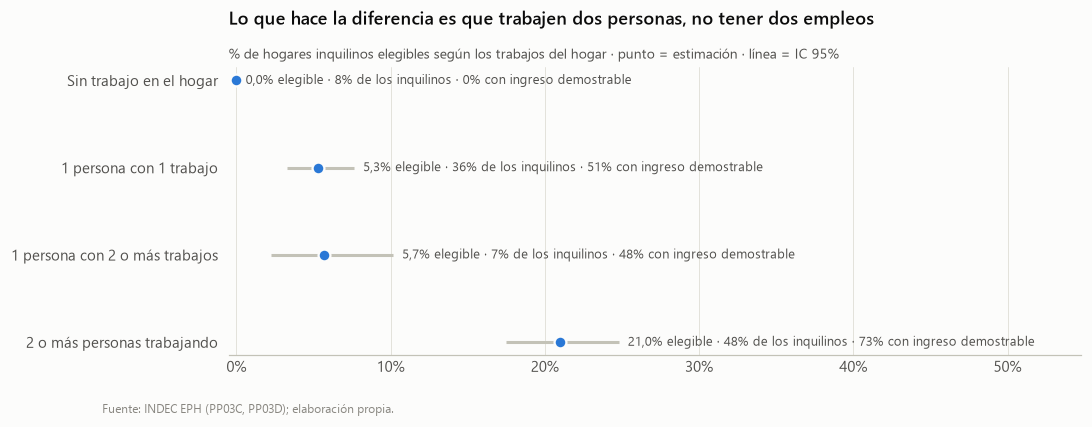

,variable,grupo,muestra_hogares,hogares,pct_de_inquilinos,ingreso_mediano,pct_con_ingreso_demostrable,pct_pasan_cuota_y_anticipo,pct_elegible,ic95_inf,ic95_sup,hogares_elegibles
0,fuentes_trabajo,1 trabajo,647,"450,359.20",36.20,"1,621,741.90",50.80,9.80,5.30,3.30,7.60,"23,741.30"
1,fuentes_trabajo,2 o más trabajos,755,"690,942.50",55.50,"2,817,965.70",69.40,24.90,19.00,15.70,22.20,"131,051.80"
2,fuentes_trabajo,Sin trabajo en el hogar,205,"103,486.00",8.30,"916,863.10",0.00,3.10,0.00,0.00,0.00,0.00
3,detalle_trabajo,1 persona con 1 trabajo,647,"450,359.20",36.20,"1,621,741.90",50.80,9.80,5.30,3.30,7.60,"23,741.30"
4,detalle_trabajo,1 persona con 2 o más trabajos,150,"90,998.80",7.30,"1,869,785.00",47.90,17.80,5.70,2.20,10.10,"5,185.10"
5,detalle_trabajo,2 o más personas trabajando,614,"599,943.80",48.20,"2,963,090.90",72.70,26.00,21.00,17.50,24.80,"125,866.70"
6,detalle_trabajo,Sin trabajo en el hogar,205,"103,486.00",8.30,"916,863.10",0.00,3.10,0.00,0.00,0.00,0.00


{'elegibles_ingreso_hogar': np.float64(154793.1357999695),
 'elegibles_solo_titulares': np.float64(139724.8185157074),
 'diferencia_hogares': np.float64(15068.317284262099),
 'diferencia_pct': np.float64(-9.73448674347811),
 'pct_ingreso_de_otros_miembros': np.float64(7.296367930161796)}

In [13]:
fu = A.acceso_por_fuentes(h, m, base)
det = fu[fu.variable == "detalle_trabajo"].set_index("grupo").loc[["Sin trabajo en el hogar", "1 persona con 1 trabajo", "1 persona con 2 o más trabajos", "2 o más personas trabajando"]]
fig, ax = plt.subplots(figsize=(10, 3.4))
y = np.arange(len(det))[::-1]
ax.errorbar(det.pct_elegible, y, xerr=[det.pct_elegible - det.ic95_inf, det.ic95_sup - det.pct_elegible], fmt="none", ecolor=viz.BASELINE, elinewidth=2)
ax.scatter(det.pct_elegible, y, s=60, color=viz.BLUE, zorder=3, edgecolor=viz.SURFACE, linewidth=1.5)
for yi, (g, r) in zip(y, det.iterrows()):
    ax.text(max(r.ic95_sup, r.pct_elegible) + 0.6, yi, f"{fmt_pct(r.pct_elegible)} elegible · {fmt_pct(r.pct_de_inquilinos, 0)} de los inquilinos · {fmt_pct(r.pct_con_ingreso_demostrable, 0)} con ingreso demostrable", va="center", fontsize=8.5, color=viz.INK_2)
ax.set_yticks(y, det.index)
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.xaxis.set_major_formatter(viz.EJE_PCT)
ax.set_xlim(-0.5, det.ic95_sup.max() + 30)
ax.set_title("Lo que hace la diferencia es que trabajen dos personas, no tener dos empleos")
viz.subtitle(ax, "% de hogares inquilinos elegibles según los trabajos del hogar · punto = estimación · línea = IC 95%")
viz.source(fig, "INDEC EPH (PP03C, PP03D); elaboración propia.")
viz.save(fig, "03_acceso_por_trabajos")
plt.show()
display(fu.round(1)); A.escenario_solo_titulares(h, m, base)

> **Recuadro · posible punto de fuga.** Donde trabajan **dos o más personas**, califica el 21,0%; con **una persona y un trabajo**, el 5,3%. Una persona con **dos empleos** pasa más seguido los filtros de cuota y anticipo (17,8%), pero solo el 48% tiene ingreso demostrable: el segundo empleo suele ser informal. Si el banco computa solo el ingreso de **jefe/a y cónyuge**, los elegibles bajan 10%. El punto de fuga: hogares que **pueden pagar con ingresos que el banco no ve**.

## 9. Robustez: ¿la conclusión depende de los supuestos?
Tres controles pedidos en el Checkpoint 3:
1. **Censo 2022:** la EPH capta menos inquilinos → rango ajustado de hogares elegibles (notebook 02).
2. **Subdeclaración de ingresos:** la EPH capta en promedio el 93% del sueldo mediano formal que registra el SIPA (neto de aportes). Se corrigen **solo los sueldos formales** (los que tienen referencia administrativa) por la mediana y por el promedio.
3. **No respuesta:** en lugar de la reponderación del INDEC, se imputa el ingreso del 28% de inquilinos que no lo declaró, con imputación múltiple (10 imputaciones, donantes con perfil laboral y demográfico parecido).

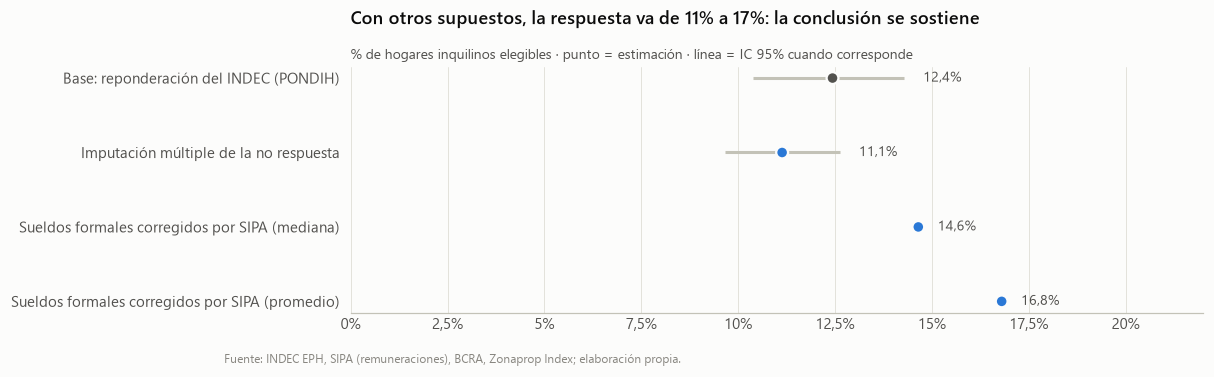

,trimestre,eph_media,sipa_media_neta,cobertura_media,eph_mediana,sipa_mediana_neta,cobertura_mediana
0,2T-2025,"1,163,575.73","1,358,222.57",0.86,"950,000.00","1,039,694.10",0.91
1,3T-2025,"1,212,485.81","1,453,593.10",0.83,"1,000,000.00","1,115,885.69",0.90
2,4T-2025,"1,336,810.18","1,531,374.93",0.87,"1,100,000.00","1,156,706.28",0.95
3,1T-2026,"1,417,837.12","1,743,643.96",0.81,"1,200,000.00","1,253,861.79",0.96


,escenario,factor_sueldo_formal,hogares_elegibles,pct_elegible
0,Sin corregir (base),1.00,"154,793.14",12.44
1,Corregido por la mediana,1.08,"182,353.67",14.65
2,Corregido por el promedio,1.19,"209,131.08",16.80


,0
repeticiones,5
pct_elegible_real_promedio,11.26
pct_elegible_imputado_promedio,11.09
error_absoluto_medio_pp,1.74
detalle,"[{'repeticion': 1, 'hogares_ocultos': 608, 'pc..."


In [14]:
cob = A.cobertura_sipa(con)
sub = A.escenario_subdeclaracion(h, m, cob, base)
nr = K["robustez"]["no_respuesta"]
filas = [
    ("Base: reponderación del INDEC (PONDIH)", K["base"]["elegibles_pct"], *K["base"]["elegibles_ic95"]),
    ("Imputación múltiple de la no respuesta", nr["pct_elegible_imputacion"]["estimacion"], nr["pct_elegible_imputacion"]["ic95_inf"], nr["pct_elegible_imputacion"]["ic95_sup"]),
    ("Sueldos formales corregidos por SIPA (mediana)", sub.pct_elegible.iloc[1], np.nan, np.nan),
    ("Sueldos formales corregidos por SIPA (promedio)", sub.pct_elegible.iloc[2], np.nan, np.nan),
]
r = pd.DataFrame(filas, columns=["escenario", "pct", "inf", "sup"])
fig, ax = plt.subplots(figsize=(10, 2.9))
y = np.arange(len(r))[::-1]
con_ic = r.inf.notna()
ax.errorbar(r.pct[con_ic], y[con_ic], xerr=[r.pct[con_ic] - r.inf[con_ic], r.sup[con_ic] - r.pct[con_ic]], fmt="none", ecolor=viz.BASELINE, elinewidth=2)
ax.scatter(r.pct, y, s=60, color=[viz.INK_2] + [viz.BLUE] * 3, zorder=3, edgecolor=viz.SURFACE, linewidth=1.5)
for yi, rr in zip(y, r.itertuples()):
    ax.text((rr.sup if pd.notna(rr.sup) else rr.pct) + 0.5, yi, fmt_pct(rr.pct), va="center", fontsize=9, color=viz.INK_2)
ax.set_yticks(y, r.escenario); ax.set_xlim(0, 22)
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True); ax.xaxis.set_major_formatter(viz.EJE_PCT)
ax.set_title(f"Con otros supuestos, la respuesta va de {fmt_pct(r.pct.min(), 0)} a {fmt_pct(r.pct.max(), 0)}: la conclusión se sostiene")
viz.subtitle(ax, "% de hogares inquilinos elegibles · punto = estimación · línea = IC 95% cuando corresponde")
viz.source(fig, "INDEC EPH, SIPA (remuneraciones), BCRA, Zonaprop Index; elaboración propia.")
viz.save(fig, "03_robustez")
plt.show()
display(cob.round(3)); display(sub.round(3)); pd.json_normalize(nr["validacion"]).T

**Lectura:** la imputación da 11,1% (IC 9,7–12,6), un poco menos que la base; en la prueba de validación (se ocultan ingresos conocidos y se imputan) el error promedio fue de 1,7 puntos. Corregir la subdeclaración de sueldos formales sube la elegibilidad a 14,6%–16,8%. **En todos los escenarios, la respuesta sigue siendo "una minoría de los inquilinos": entre 1 de cada 9 y 1 de cada 6.**

## 10. Tablero de hipótesis

In [15]:
pd.DataFrame([
    ["H1", "Menos del 20% de los inquilinos paga la cuota", "22,1% (IC 19,6–24,5); 12,4% pasa el embudo completo", "En el límite: el intervalo incluye el 20%"],
    ["H2", "La barrera es el anticipo, no la cuota", "Tope por anticipo 37,5 ingresos vs 41,4 por cuota; 78% no alcanza ninguna", "Confirmada con matiz"],
    ["H3", "Composición del hogar y elegibilidad", "Parejas sin hijos 32,9%; un solo adulto 5,8%–4,6%", "Hallazgo descriptivo (sin veredicto causal)"],
    ["H4", "La elegibilidad difiere por zona y edad", "Zonas 9,4%–16,4% (p 0,37); edad p 0,03", "Parcialmente confirmada"],
    ["H5", "Si la UVA le gana a los sueldos, la cuota supera el 30%", "sep-23: 25% → 32,9% a 24 meses", "Confirmada"],
    ["Contexto", "Stock real y tasa se mueven en sentido opuesto", "Correlación débil negativa", "Pasa a contexto de mercado"],
    ["H7", "Tener más de un trabajo mejora el acceso", "Dos personas trabajando 21,0%; una persona con dos empleos 5,7%", "Recuadro: posible punto de fuga"],
], columns=["#", "Hipótesis", "Evidencia", "Veredicto"])

,#,Hipótesis,Evidencia,Veredicto
0,H1,Menos del 20% de los inquilinos paga la cuota,"22,1% (IC 19,6–24,5); 12,4% pasa el embudo com...",En el límite: el intervalo incluye el 20%
1,H2,"La barrera es el anticipo, no la cuota","Tope por anticipo 37,5 ingresos vs 41,4 por cu...",Confirmada con matiz
2,H3,Composición del hogar y elegibilidad,"Parejas sin hijos 32,9%; un solo adulto 5,8%–4,6%",Hallazgo descriptivo (sin veredicto causal)
3,H4,La elegibilidad difiere por zona y edad,"Zonas 9,4%–16,4% (p 0,37); edad p 0,03",Parcialmente confirmada
4,H5,"Si la UVA le gana a los sueldos, la cuota supe...","sep-23: 25% → 32,9% a 24 meses",Confirmada
5,Contexto,Stock real y tasa se mueven en sentido opuesto,Correlación débil negativa,Pasa a contexto de mercado
6,H7,Tener más de un trabajo mejora el acceso,"Dos personas trabajando 21,0%; una persona con...",Recuadro: posible punto de fuga


In [16]:
con.close()